#### 2. Transaction EDA

Após o entendimento do problema de negócio e da estrutura geral do projeto, o próximo passo consiste na realização da análise exploratória dos dados transacionais (train_transaction.csv).

O objetivo deste notebook é investigar o comportamento das transações financeiras e identificar padrões iniciais associados à fraude. Nesta etapa, a análise será realizada exclusivamente sobre o dataset transacional, sem utilização das informações de identidade, permitindo compreender o comportamento financeiro básico do sistema antes da adição de contexto comportamental mais complexo.

##### 2.1 Bibliotecas & Carregamento dos dados

In [ ]:
# 2.1.1 Bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)


In [ ]:
# 2.1.2 Carregamento dos dados
df = pd.read_csv("../data/train_transaction.csv")

In [ ]:
# 2.1.3 Visão geral dos dados
print(df.shape)
df.head()

(590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,...,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

##### 2.2 Análise da variável target

Em problemas de fraude financeira, é esperado que o dataset seja altamente desbalanceado, já que transações fraudulentas representam apenas uma pequena fração do total de operações realizadas.

In [ ]:
# 2.2.1 Análise da variável target
df["isFraud"].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

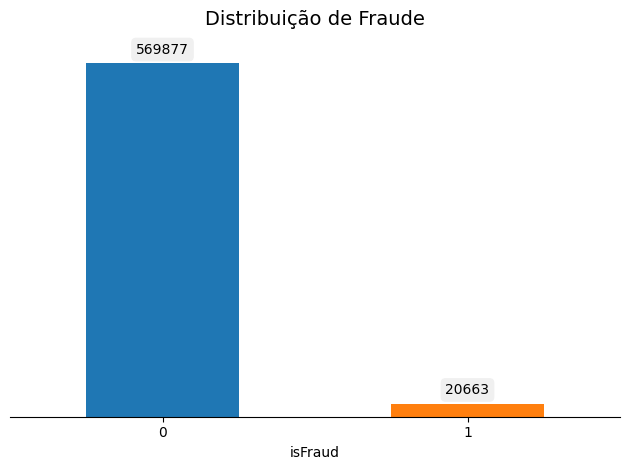

In [26]:
# 2.2.2 Visualização da variável target
ax = df["isFraud"].value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"])

# 2. Rotaciona os rótulos do eixo X para a horizontal (0 graus)
plt.xticks(rotation=0)

# 3. Remove o eixo Y (linhas, ticks e valores)
ax.get_yaxis().set_visible(False)
ax.spines["left"].set_visible(False)  # Remove a linha lateral esquerda
ax.spines["top"].set_visible(False)   # Remove a linha superior
ax.spines["right"].set_visible(False) # Remove a linha da direita

# 4. Adiciona os valores em cima das barras (estilo badge)
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    # Adiciona o texto com um "box" ao redor para dar o efeito de badge
    ax.annotate(
        f"{int(height)}", 
        (x + width / 2, height), 
        ha="center", 
        va="bottom",
        xytext=(0, 5),               # Desloca o texto 5 pontos para cima da barra
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="#f0f0f0") # O "badge"
    )

# 5. Título e exibição
plt.title("Distribuição de Fraude", fontsize=14, pad=15)
plt.tight_layout()
plt.show()



A visualização do gráfico acima (Distribuição de Fraude) evidencia o desbalanceamento que caracteriza o cenário de fraudes financeiras, revelando que aproximadamente 96,5% da base histórica corresponde a transações legítimas, enquanto que apenas 3,5% representa movimentações fraudulentas.

##### 2.3 Análise da variável TransactionAmt

A variável TransactionAmt representa o valor monetário da transação em dólares.

A análise dessa variável busca identificar:

distribuição financeira das transações
presença de outliers
assimetria dos dados
diferenças entre fraude e não fraude

Além disso, parte das transações possui três casas decimais, o que pode indicar operações internacionais ou conversões cambiais.

In [ ]:
# 2.3.1 Análise descritiva da variável TransactionAmt
df["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

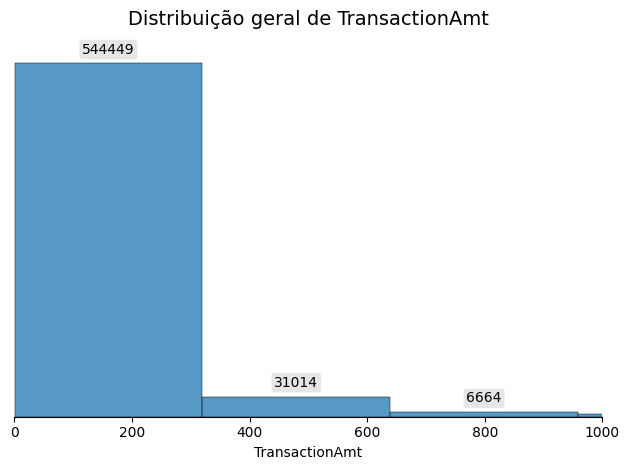

In [ ]:
# 2.3.2 Distribuição geral
# 1. Cria o gráfico e captura o eixo (ax)
ax = sns.histplot(df["TransactionAmt"], bins=100, color="#1f77b4")
plt.xlim(0, 1000)

# 2. Garante que os rótulos do eixo X fiquem na horizontal
plt.xticks(rotation=0)

# 3. Remove o eixo Y e as linhas de contorno do gráfico
ax.get_yaxis().set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 4. Adiciona os valores em cima das barras principais (sem borda no badge)
# Descobre a altura da maior barra para criar um filtro proporcional
max_height = max([p.get_height() for p in ax.patches if p.get_height() > 0])

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue
    
    width = p.get_width()
    x, y = p.get_xy()
        
    ax.annotate(
        f"{int(height)}", 
        (x + width / 2, height), 
        ha="center", 
        va="bottom",
        xytext=(0, 5),               # 5 pontos de folga acima da barra
        textcoords="offset points",
        fontsize=10,
        # Badge flat: fc é a cor de fundo, lw=0 remove a borda
        bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="#f0f0f0") # O "badge"
    )

# 5. Título e exibição
plt.title("Distribuição geral de TransactionAmt", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

O histograma 'Distribuição geral de TransactionAmt' indica que a grande maioria das transações, que representam as movimentações cotidianas do sistema, está concentrada em faixas de valores menores, especificamente entre USD 0,00 e USD 300,00. Esse comportamento visual evidencia uma forte assimetria à direita no conjunto de dados, confirmando que compras de tickets mais baixos são predominantes no volume total de registros

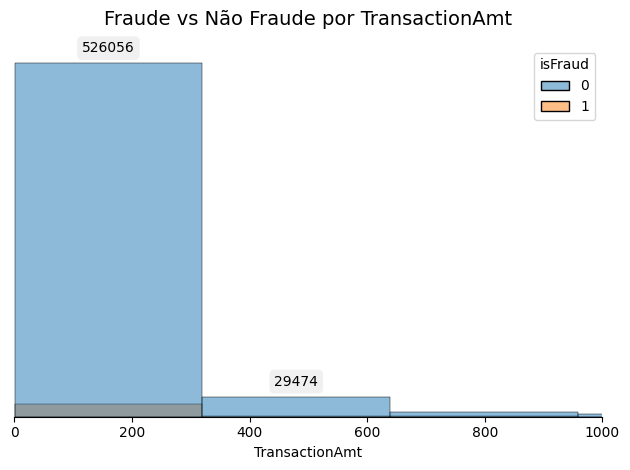

In [37]:
# 2.3.3 Fraude vs não fraude

# 1. Cria o gráfico e captura o eixo (ax)
# Defini as cores explicitamente para podermos usá-las nos badges depois
cores = {0: "#1f77b4", 1: "#ff7f0e"} 
ax = sns.histplot(data=df, x="TransactionAmt", hue="isFraud", bins=100, palette=cores)
plt.xlim(0, 1000)

# 2. Rótulos do eixo X na horizontal
plt.xticks(rotation=0)

# 3. Limpa o eixo Y e as bordas
ax.get_yaxis().set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 4. Adiciona os valores (badges dinâmicos por categoria)
max_height = max([p.get_height() for p in ax.patches if p.get_height() > 0])

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue
        
    # Filtro para não poluir o gráfico (mostra apenas barras relevantes)
    if height > (max_height * 0.05):
        width = p.get_width()
        x, y = p.get_xy()
        
        # O Seaborn pinta as barras na ordem do hue. Descobrimos a cor da barra atual:
        cor_da_barra = p.get_facecolor()
        
        ax.annotate(
            f"{int(height)}", 
            (x + width / 2, height), 
            ha="center", 
            va="bottom",
            xytext=(0, 6),               # Um pouquinho mais alto para não colar na barra
            textcoords="offset points",
            fontsize=10,
            # O badge assume a mesma cor da barra atual (cor_da_barra) e sem bordas (lw=0)
            bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="#f0f0f0") # O "badge" 
        )

# 5. Título e exibição
plt.title("Fraude vs Não Fraude por TransactionAmt", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Esta visualização segmenta os valores transacionais comparando diretamente as operações legítimas em relação às fraudulentas. O gráfico auxilia a compreender se as fraudes se concentram em compras de menor valor para passar despercebidas pelos sistemas de monitoramento ou se buscam capturar quantias elevadas em uma única investida criminosa

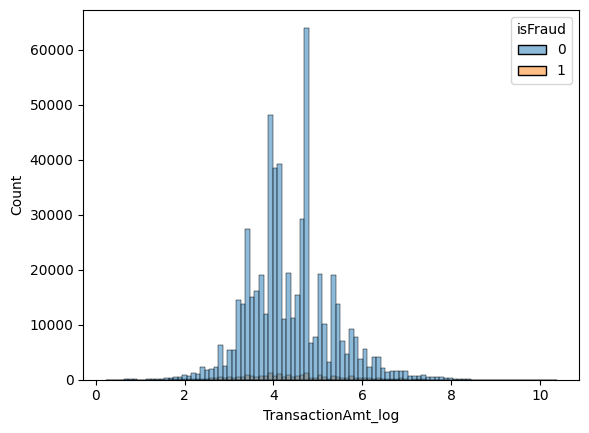

In [ ]:
# 2.3.4 Transformação log
"""
Devido à forte assimetria da variável, uma transformação logarítmica
pode ajudar a reduzir skewness e melhorar futuras etapas de modelagem
"""

df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])

# 📊 Após log
sns.histplot(data=df, x="TransactionAmt_log", hue="isFraud", bins=100)
plt.show()

A análise do histograma após a aplicação da transformação logarítmica (TransactionAmt_log) revela que as transações fraudulentas não se caracterizam por apresentar valores excessivamente elevados. A distribuição das fraudes (identificada em laranja) sobrepõe-se quase perfeitamente à distribuição das transações legítimas, concentrando-se nas faixas de valores centrais e mais comuns do sistema. Esse comportamento indica que os fraudadores operam predominantemente dentro dos limites transacionais cotidianos para evitar a detecção por regras simples de outliers de valor, evidenciando a necessidade de variáveis contextuais mais complexas para a separação das classes.

##### 2.4 Análise temporal (TransactionDT)

A variável TransactionDT representa um tempo relativo em segundos a partir de uma data de referência interna do sistema.

Embora não represente timestamps reais, ela permite investigar:

distribuição temporal das transações
padrões de atividade
concentração temporal de fraudes
possíveis “ondas” de comportamento fraudulento

In [ ]:
# 2.4.1 Análise temporal da variável TransactionDT
df["TransactionDT"].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

C:\Users\u513127\AppData\Local\Temp\ipykernel_354476\3973474335.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Transaction_Days"] = df["TransactionDT"] / 86400


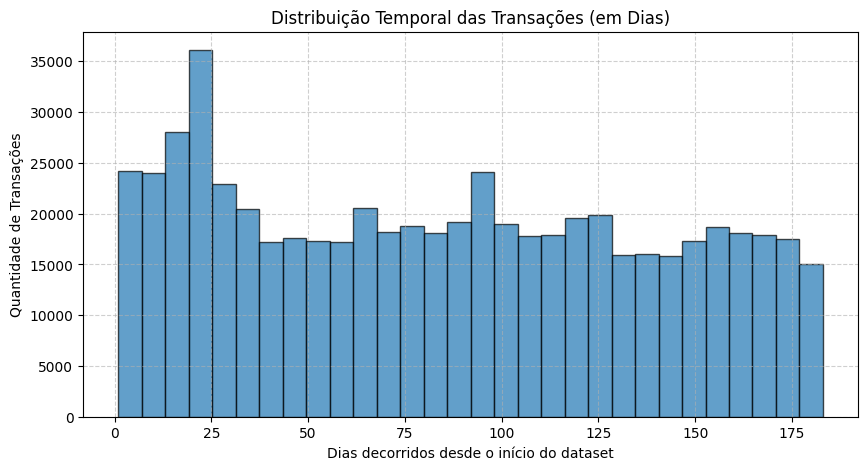

In [42]:
# 2.4.2 Distribuição do tempo
# 1. Cria a coluna convertendo os segundos em dias
df["Transaction_Days"] = df["TransactionDT"] / 86400

# 2. Plota o gráfico agora em uma escala real de dias
plt.figure(figsize=(10, 5))
plt.hist(df["Transaction_Days"], bins=30, edgecolor='k', alpha=0.7)
plt.title("Distribuição Temporal das Transações (em Dias)")
plt.xlabel("Dias decorridos desde o início do dataset")
plt.ylabel("Quantidade de Transações")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Após a conversão da variável TransactionDT de segundos para dias (Transaction_Days), a distribuição temporal revela que o conjunto de dados cobre uma janela histórica contínua de 180 dias (6 meses). O histograma demonstra uma distribuição volumétrica homogênea e consistente ao longo de todo o período, sem indícios de perda de dados ou quedas abruptas de monitoramento.

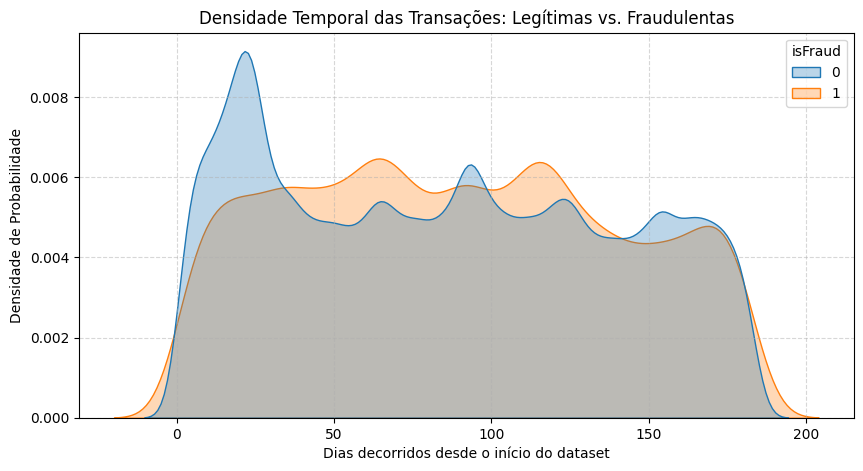

In [43]:
# 2.4.3 Fraude ao longo do tempo
if "Transaction_Days" not in df.columns:
    df["Transaction_Days"] = df["TransactionDT"] / 86400

# 📊 Densidade de Fraude ao longo do tempo (em Dias)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="Transaction_Days", hue="isFraud", common_norm=False, fill=True, alpha=0.3)
plt.title("Densidade Temporal das Transações: Legítimas vs. Fraudulentas")
plt.xlabel("Dias decorridos desde o início do dataset")
plt.ylabel("Densidade de Probabilidade")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

No mundo real, as fraudes são apenas uma fração minúscula do total de dados (cerca de 3.5%). Se desenhássemos um gráfico normal, a linha laranja ficaria colada ao chão e não conseguiríamos ver nada. Com o parâmetro `common_norm=False`, usamos o mesmo peso de dados para as duas categorias. A área total sob a curva azul é igual a 1, e a área sob a curva laranja também é igual a 1. Dessa forma, o gráfico mostra quando houve uma maior concentração de transações legítimas ou fraudulentas durante os 6 meses presentes no dataset.

##### 2.5 Análise de missing values

Datasets de fraude frequentemente apresentam altos níveis de valores ausentes, especialmente em variáveis relacionadas a:

- autenticação
- identidade
- relacionamento entre entidades
- contexto da transação

Em problemas de fraude, ausência de informação pode representar um sinal relevante.

In [16]:
# 2.5.1 Missing por coluna
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V149     0.861237
V141     0.861237
V146     0.861237
V154     0.861237
V162     0.861237
V142     0.861237
V158     0.861237
V161     0.861237
V157     0.861237
V138     0.861237
V139     0.861237
dtype: float64

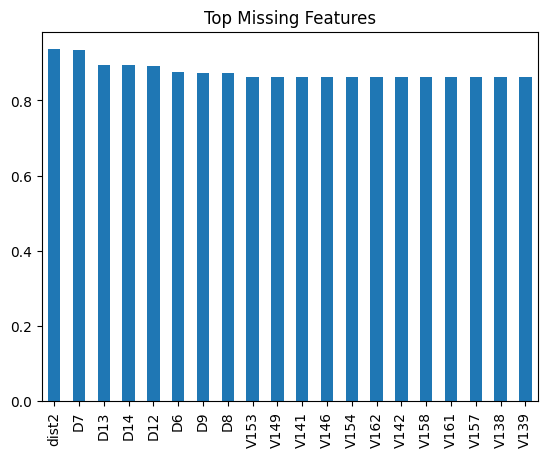

In [ ]:
# 2.5.2 Visualização das variáveis que apresentam maior proporção de missing
missing[missing > 0].head(20).plot(kind="bar")
plt.title("Top Missing Features")
plt.show()

In [18]:
# 2.5.3 Missing por linha
df["missing_count"] = df.isnull().sum(axis=1)

C:\Users\u513127\AppData\Local\Temp\ipykernel_354476\2239682679.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["missing_count"] = df.isnull().sum(axis=1)


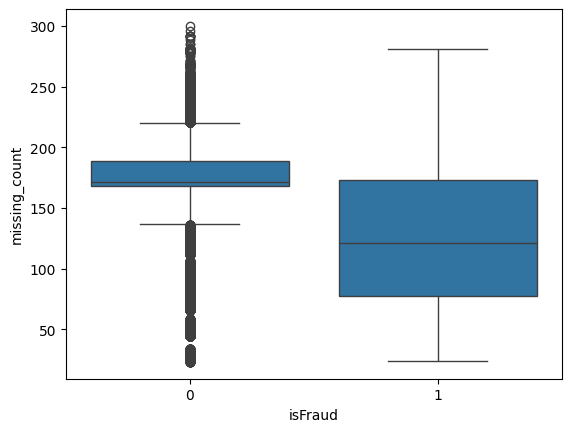

In [ ]:
# 2.5.4 Relação entre missing e fraude
sns.boxplot(x='isFraud', y='missing_count', data=df)
plt.show()

#### 2.6 Análise de variáveis categóricas

- ProductCD - representa a categoria do produto ou serviço associado à transação.

- Card Features - `card1` - `card6` representam informações relacionadas ao cartão e à instituição financeira.

- Email Domains - as variáveis `P_emaildomain`e `R_emaildomain` representam os domínios do email do comprador e do destinatário

In [ ]:
# 2.6.1 Análise da variável ProductCD
df["ProductCD"].value_counts(normalize=True)

ProductCD
W    0.744522
C    0.116028
R    0.063838
H    0.055922
S    0.019690
Name: proportion, dtype: float64

A distribuição observada mostra forte concentração na categoria W, responsável por aproximadamente 74% de todas as transações do dataset.

Essa distribuição indica que o sistema financeiro analisado possui um tipo predominante de operação, enquanto as demais categorias representam segmentos menores do fluxo transacional.

A presença de categorias menos frequentes pode ser relevante para fraude, já que atividades maliciosas muitas vezes se concentram em determinados tipos de produto ou serviço.

In [ ]:
# 2.6.2 Análise das variáveis card1 a card6
card_cols = [
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6"
]

df[card_cols].head()

,card1,card2,card3,card4,card5,card6
0,13926,NaN,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


A análise inicial sugere que:

- `card4` representa a bandeira do cartão, contendo categorias como Visa, Mastercard e Discover

- `card6` representa o tipo do cartão, como crédito (credit) ou débito (debit)

- as variáveis numéricas (`card1`, `card2`, `card3` e `card5`) aparentam representar identificadores internos relacionados ao banco emissor, categoria financeira ou agrupamentos específicos do sistema

Também é possível observar a presença de valores ausentes (NaN) em algumas features, especialmente em card2, indicando que nem todas as transações possuem todas as informações financeiras disponíveis

In [40]:
# 2.6.3 Análise da variável P_emaildomain
df["P_emaildomain"].value_counts().head(10)

P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
Name: count, dtype: int64

A distribuição é dominada por provedores amplamente utilizados, como Gmail e Yahoo. Entretanto, chama atenção a presença significativa do domínio anonymous.com, que pode indicar ocultação de identidade, serviços temporários ou ainda
mascaramento de origem. Esse tipo de comportamento pode ser relevante para detecção de fraude.

In [41]:
# 2.6.4 Fraude por domínio de email
pd.crosstab(
    df["P_emaildomain"],
    df["isFraud"],
    normalize="index"
).head(10)

isFraud,0,1
P_emaildomain,,
aim.com,0.873016,0.126984
anonymous.com,0.976783,0.023217
aol.com,0.978189,0.021811
att.net,0.992561,0.007439
bellsouth.net,0.972237,0.027763
cableone.net,0.981132,0.018868
centurylink.net,1.000000,0.000000
cfl.rr.com,1.000000,0.000000
charter.net,0.969363,0.030637


Observa-se que alguns domínios apresentam taxas de fraude significativamente superiores à média geral do dataset.

O domínio aim.com, por exemplo, apresenta uma proporção de fraude muito elevada em comparação aos demais. Isso pode indicar:

- comportamento de nicho
- baixa quantidade de usuários legítimos
- utilização preferencial em atividades suspeitas

Já domínios mais tradicionais apresentam taxas menores e comportamento aparentemente mais estável.

Além disso, alguns domínios possuem taxa de fraude igual a zero dentro da amostra analisada. Entretanto, esse comportamento deve ser interpretado com cautela, pois pode ser consequência de baixa representatividade estatística.

#### 2.7 Hipóteses iniciais


In [44]:
df.groupby("isFraud")["TransactionAmt"].mean()

isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

In [45]:
df.groupby("isFraud")["missing_count"].mean()

isFraud
0    162.784041
1    135.498476
Name: missing_count, dtype: float64

In [46]:
df.groupby("isFraud")["TransactionDT"].mean()

isFraud
0    7.360791e+06
1    7.690033e+06
Name: TransactionDT, dtype: float64